Key Components

1.State Management: Utilizes a MusicState class to manage the workflow's state.
2.Language Model: Employs LLAMA-3.3 Model generating musical components.
3. Musical Functions:
4. Melody Generator
5. Harmony Creator
6. Rhythm Analyzer
7. Style Adapter

MIDI Conversion: Transforms the composition into a playable MIDI file.
LangGraph Workflow: Orchestrates the composition process using a state graph.
Playback Functionality: Allows for immediate playback of the generated composition.

In [3]:
pip install langchain langchain-core langgraph langchain-community langchain-groq
from dotenv import load_dotenv
load_dotenv()

SyntaxError: invalid syntax (245998363.py, line 1)

In [23]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
import music21 
import tempfile 

import random

In [24]:
class MusicState(TypedDict):
    musician_input: str
    melody: str
    harmony:str
    rhythm: str
    style: str
    composition: str
    midi_file:str

2.LLM Initialization 

In [4]:
from langchain_groq import ChatGroq
import os

llm= ChatGroq(
    temperature =0,
    groq_api_key= os.getenv("GROQ_API_KEY"),
    model_name= "llama-3.3-70b-versatile"
)

result= llm.invoke("What is music?")

j:\ML_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [26]:
print(result.content)

Music is a universal language that has been a part of human culture for thousands of years. It is a form of artistic expression that uses sound and silence to convey emotions, ideas, and experiences. Music can be defined as:

1. **An arrangement of sounds**: Music is created by combining different sounds, such as melodies, harmonies, rhythms, and timbres, to produce a unique auditory experience.
2. **A form of communication**: Music can express emotions, tell stories, and convey messages, making it a powerful tool for communication and connection.
3. **A cultural phenomenon**: Music is shaped by cultural, social, and historical contexts, reflecting the values, traditions, and experiences of different societies and communities.
4. **A creative expression**: Music is an art form that allows individuals to express themselves, their thoughts, and their feelings through composition, performance, and improvisation.

Music can take many forms, including:

* **Vocal music**: Singing, chanting,

In [27]:
# 3. Musical Node Function 

def melody_generator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Generate a melody based on this input: {input}. Represent it as a string of notes in music21 format"
  )
  chain = prompt | llm
  melody = chain.invoke({"input": state["musician_input"]})
  return {"melody":melody.content}

def harmony_creator(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Create harmony for this melody: {melody}. Represent it as a string of chords in music21 format"
  )
  chain = prompt | llm
  harmony = chain.invoke({"melody": state["melody"]})
  return {"harmony":harmony.content}

def rhythm_analyzer(state: MusicState) -> Dict:
  prompt = ChatPromptTemplate.from_template(
      "Analyze and suggest a rhythm for this melody and harmony: {melody},{harmony}. Represent it as a string of duration in music21 format"
  )
  chain = prompt | llm
  rhythm = chain.invoke({"melody": state["melody"], "harmony": state["harmony"]})
  return {"rhythm":rhythm.content}

def style_adapter(state: MusicState)->Dict:
  prompt = ChatPromptTemplate.from_template(
      "Adapt this composition to the {style} style: Melody: {melody}, Harmony: {harmony}, Rhythm: {rhythm}. Provide the result in music21 format"
  )
  chain = prompt | llm
  adapted = chain.invoke(
      {
          "style": state["style"],
          "melody" : state["melody"],
          "harmony":state["harmony"],
          "rhythm":state["rhythm"]
      }
  )
  return {"composition": adapted.content}

In [28]:
# MIDI Conversion

def midi_converter(state: MusicState)->Dict:
  piece = music21.stream.Score()
  description = music21.expressions.TextExpression(state["composition"])
  piece.append(description)

  scales = {
        'C major': ['C', 'D', 'E', 'F', 'G', 'A', 'B'],
        'C minor': ['C', 'D', 'Eb', 'F', 'G', 'Ab', 'Bb'],
        'C harmonic minor': ['C', 'D', 'Eb', 'F', 'G', 'Ab', 'B'],
        'C melodic minor': ['C', 'D', 'Eb', 'F', 'G', 'A', 'B'],
        'C dorian': ['C', 'D', 'Eb', 'F', 'G', 'A', 'Bb'],
        'C phrygian': ['C', 'Db', 'Eb', 'F', 'G', 'Ab', 'Bb'],
        'C lydian': ['C', 'D', 'E', 'F#', 'G', 'A', 'B'],
        'C mixolydian': ['C', 'D', 'E', 'F', 'G', 'A', 'Bb'],
        'C locrian': ['C', 'Db', 'Eb', 'F', 'Gb', 'Ab', 'Bb'],
        'C whole tone': ['C', 'D', 'E', 'F#', 'G#', 'A#'],
        'C diminished': ['C', 'D', 'Eb', 'F', 'Gb', 'Ab', 'A', 'B'],
    }

  chords = {
        'C major': ['C4', 'E4', 'G4'],
        'C minor': ['C4', 'Eb4', 'G4'],
        'C diminished': ['C4', 'Eb4', 'Gb4'],
        'C augmented': ['C4', 'E4', 'G#4'],
        'C dominant 7th': ['C4', 'E4', 'G4', 'Bb4'],
        'C major 7th': ['C4', 'E4', 'G4', 'B4'],
        'C minor 7th': ['C4', 'Eb4', 'G4', 'Bb4'],
        'C half-diminished 7th': ['C4', 'Eb4', 'Gb4', 'Bb4'],
        'C fully diminished 7th': ['C4', 'Eb4', 'Gb4', 'A4'],
    }

  def create_melody(scale_name, duration):
    melody = music21.stream.Part()
    scale = scales[scale_name]
    for i in range(duration):
      note = music21.note.Note(random.choice(scale) + '4')
      note.quarterLength = 1
      melody.append(note)
    return melody

  def create_chord_progression(duration):
    harmony = music21.stream.Part()
    for i in range(duration):
      chord_name = random.choice(list(chords.keys()))
      chord = music21.chord.Chord(chords[chord_name])
      chord.quarterLength = 1
      harmony.append(chord)
    return harmony

  user_input = state["musician_input"].lower()

  if 'minor' in user_input:
    scale_name = 'C minor'
  elif 'major' in user_input:
    scale_name = 'C major'
  else:
    scale_name = random.choice(list(scales.keys()))

  melody = create_melody(scale_name, 10)
  harmony = create_chord_progression(10)

  final_note = music21.note.Note(scales[scale_name][0] + '4')
  final_note.quarterLength = 1
  melody.append(final_note)

  final_chords = music21.chord.Chord(chords[scale_name.split()[0] + ' ' + scale_name.split()[1]])
  final_chords.quarterLength = 1
  harmony.append(final_chords)

  piece.append(melody)
  piece.append(harmony)

  piece.insert(0, music21.tempo.MetronomeMark(number = 60))

  with tempfile.NamedTemporaryFile(delete =False, suffix=".mid") as temp_midi:
    piece.write('midi', temp_midi.name)
  return {"midi_file": temp_midi.name}

In [29]:
#5. Langgraph Workflow 

workflow = StateGraph(MusicState)

workflow.add_node("melody_generator", melody_generator)
workflow.add_node("harmony_creator", harmony_creator)
workflow.add_node("rhythm_analyzer", rhythm_analyzer)
workflow.add_node("style_adapter", style_adapter)
workflow.add_node("midi_converter", midi_converter)

workflow.set_entry_point("melody_generator")

workflow.add_edge("melody_generator", "harmony_creator")
workflow.add_edge("harmony_creator", "rhythm_analyzer")
workflow.add_edge("rhythm_analyzer", "style_adapter")
workflow.add_edge("style_adapter", "midi_converter")
workflow.add_edge("midi_converter", END)

app= workflow.compile()

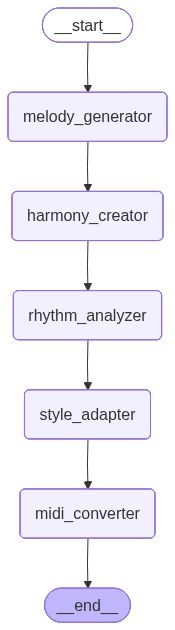

In [30]:
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method= MermaidDrawMethod.API
        )
    )
)

In [31]:
#Run The WorkFlow


inputs = {
    "musician_input": "Write a sorrowful string quartet in C minor",
    "style": "Romantic era"

}

result = app.invoke(inputs)
print(f"MIDI File saved in {result['midi_file']}")


MIDI File saved in C:\Users\adity\AppData\Local\Temp\tmpd9na6vwr.mid


In [33]:
!pip install midi2audio


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:

!apt install fluidsynth
!cp /usr/share/sounds/sf2/FluidR3_GM.sf2 ./font.sf2
!fluidsynth -ni font.sf2 /tmp/tmpmiooimc2.mid -F output.wav -r 44100

'apt' is not recognized as an internal or external command,
operable program or batch file.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'fluidsynth' is not recognized as an internal or external command,
operable program or batch file.


In [38]:
from IPython.display import Audio
Audio("output.wav")

ValueError: rate must be specified when data is a numpy array or list of audio samples.